# Sensor.Community quickstart — PM over a city

[Sensor.Community](https://sensor.community/) is a global network of low-cost,
citizen-operated air sensors. This notebook pulls PM2.5 and PM10 over a
sensor-dense area around **Stuttgart** for one recent day and plots the readings.

The `earthlens` backend is **tabular**: `download()` returns a long-format
`pandas.DataFrame`. It discovers active sensors in the bbox via the live API, then
fetches each sensor's per-day archive CSV.

> **Public & keyless, ODbL.** No credentials and no extra install — the backend uses
> core `requests` + `pandas`. Readings are crowdsourced from low-cost sensors (not
> reference-grade) and licensed under the ODbL; `download()` emits a `LicenseWarning`,
> silenced here after acknowledgement.

## Setup

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt

from earthlens.core import EarthLens
from earthlens.sensor_community import Catalog, LicenseWarning

warnings.simplefilter("ignore", LicenseWarning)  # ODbL acknowledged

## The pollutant catalog

`variables` names pollutants, mapped to CSV columns + serving sensor types.

In [2]:
sorted(Catalog().pollutants), Catalog().columns_for(["pm25", "pm10"])

(['humidity', 'pm1', 'pm10', 'pm25', 'pressure', 'temperature'],
 {'P2': 'pm25', 'P1': 'pm10'})

## Build the request

Pick a recent day and a small, sensor-dense bbox — discovery uses the *live*
snapshot, so only sensors currently active in the bbox are found, and one day over a
city already returns thousands of readings.

In [3]:
client = EarthLens(
    data_source="sensor-community",
    variables=["pm25", "pm10"],
    start="2026-06-30",
    end="2026-06-30",
    lat_lim=[48.76, 48.80],   # central Stuttgart — a handful of sensors
    lon_lim=[9.16, 9.21],
    path="out/sensor_community",
)

## Download the readings

In [4]:
df = client.download(progress_bar=False)
print(df.shape)
df.head()

2026-07-03 01:29:29.259 | INFO     | earthlens.sensor_community.backend:download:377 - Sensor.Community download summary: 51536 reading(s) across 21 sensor(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\air-quality\docs\examples\sensor-community\out\sensor_community\sensor_community_pm25-pm10_20260630_20260630.csv


(51536, 9)


,station_id,sensor_type,parameter,datetime_utc,value,units,lat,lon,provider
0,11741,SDS011,pm25,2026-06-30 00:02:05+00:00,4.60,µg/m³,48.771449,9.183695,sensor.community
1,11741,SDS011,pm25,2026-06-30 00:04:49+00:00,4.53,µg/m³,48.771449,9.183695,sensor.community
2,11741,SDS011,pm25,2026-06-30 00:07:33+00:00,5.43,µg/m³,48.771449,9.183695,sensor.community
3,11741,SDS011,pm25,2026-06-30 00:10:17+00:00,4.73,µg/m³,48.771449,9.183695,sensor.community
4,11741,SDS011,pm25,2026-06-30 00:13:01+00:00,5.13,µg/m³,48.771449,9.183695,sensor.community


## Plot PM2.5 across the day

One line per sensor for the busiest few sensors (a city bbox can hold many).

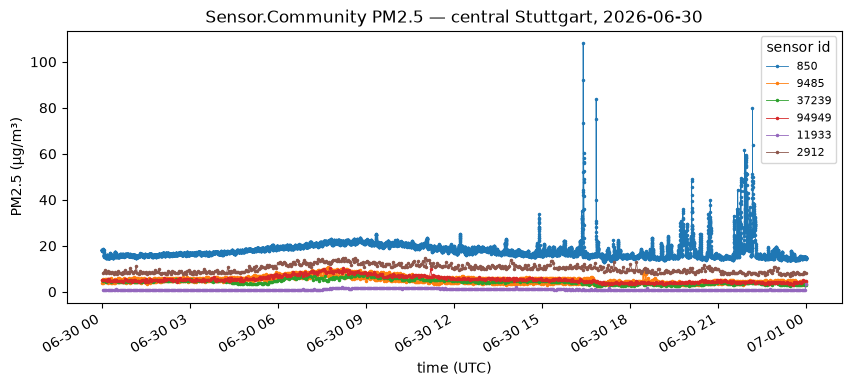

In [5]:
if not df.empty:
    pm25 = df[df["parameter"] == "pm25"]
    top = pm25["station_id"].value_counts().head(6).index
    fig, ax = plt.subplots(figsize=(10, 4))
    for sid in top:
        group = pm25[pm25["station_id"] == sid].sort_values("datetime_utc")
        ax.plot(group["datetime_utc"], group["value"], marker=".", ms=3, lw=0.6, label=str(sid))
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_xlabel("time (UTC)")
    ax.set_title("Sensor.Community PM2.5 — central Stuttgart, 2026-06-30")
    ax.legend(title="sensor id", fontsize=8)
    fig.autofmt_xdate()
    plt.show()